In [1]:
import polars as pl
import numpy as np
import pandas as pd
import math
from typing import Optional
import re
import os

def calculate_metrics_from_confusion_matrix(matrix_path):
    """
    Calculates ACC, Sn, Sp, F1, and MCC from a binary or multiclass confusion matrix CSV.
    Rows = true labels, Columns = predicted labels.
    """
    df = pd.read_csv(matrix_path, index_col=0)

    # Normalize names
    df.index = df.index.astype(str)
    df.columns = df.columns.astype(str)

    # Remove totals or metadata rows/columns
    drop_labels = {"all", "total", "real"}
    df = df.loc[~df.index.str.lower().isin(drop_labels)]
    df = df.loc[:, ~df.columns.str.lower().isin(drop_labels)]

    common_labels = df.index.intersection(df.columns)
    df = df.loc[common_labels, common_labels]

    C = df.values.astype(float)
    n_classes = C.shape[0]
    total = C.sum()

    # ------------------ Binary case ------------------
    if n_classes == 2:
        TN, FP = C[0, 0], C[0, 1]
        FN, TP = C[1, 0], C[1, 1]

        ACC = (TP + TN) / total if total > 0 else 0
        Sn = TP / (TP + FN) if (TP + FN) > 0 else 0
        Sp = TN / (TN + FP) if (TN + FP) > 0 else 0

        denom = (TP + FP) * (TP + FN) * (TN + FP) * (TN + FN)
        MCC = ((TP * TN) - (FP * FN)) / np.sqrt(denom) if denom > 0 else 0

        return {
            "ACC_test": ACC,
            "Sn_test": Sn,
            "Sp_test": Sp,
            "MCC_test": MCC,
        }

    # ------------------ Multiclass case ------------------
    TP = np.diag(C)
    FP = C.sum(axis=0) - TP
    FN = C.sum(axis=1) - TP
    TN = total - (TP + FP + FN)

    recall = np.divide(TP, TP + FN, out=np.zeros_like(TP), where=(TP + FN) > 0)
    specificity = np.divide(TN, TN + FP, out=np.zeros_like(TN), where=(TN + FP) > 0)
    precision = np.divide(TP, TP + FP, out=np.zeros_like(TP), where=(TP + FP) > 0)

    f1 = np.divide(
        2 * precision * recall,
        precision + recall,
        out=np.zeros_like(precision),
        where=(precision + recall) > 0,
    )

    ACC = TP.sum() / total if total > 0 else 0
    Sn_macro = recall.mean()
    Sp_macro = specificity.mean()

    # Multiclass MCC (Gorodkin / sklearn)
    row_sum = C.sum(axis=1)
    col_sum = C.sum(axis=0)
    numerator = np.trace(C) * total - np.dot(row_sum, col_sum)
    denominator = np.sqrt(
        (total**2 - np.sum(col_sum**2)) *
        (total**2 - np.sum(row_sum**2))
    )
    MCC = numerator / denominator if denominator > 0 else 0

    return {
        "ACC_test": ACC,
        "Sn_test": Sn_macro,
        "Sp_test": Sp_macro,
        "MCC_test": MCC
    }

# ---------- Main pipeline ----------
pl.Config(tbl_rows=60)

full_datasets_path = "App/datasets"
datasets_list = [
    os.path.join(full_datasets_path, item)
    for item in os.listdir(full_datasets_path)
    if os.path.isdir(os.path.join(full_datasets_path, item))
]

df_metrics = pd.DataFrame()

for dataset_path in datasets_list:
    experiments_folder = os.path.join(dataset_path, "runs")
    if os.path.exists(experiments_folder):
        runs_folders = [
            os.path.join(experiments_folder, run_folder)
            for run_folder in os.listdir(experiments_folder)
        ]

        for run_folder in runs_folders:
            run_num = int(re.search(r"\d+", run_folder.split("/")[-1]).group())

            if run_num >= 1 and run_num <= 5:
                # --- Load training metrics ---
                train_path = os.path.join(run_folder, "training_kfold(10)_metrics.csv")
                if not os.path.exists(train_path):
                    continue

                df_metrics_run = pd.read_csv(train_path)
                df_metrics_run["dataset"] = dataset_path.split("/")[-1]

                # --- Load test confusion matrix & compute metrics ---
                test_confusion_path = os.path.join(run_folder, "test_confusion_matrix.csv")
                test_other_path = os.path.join(run_folder, "metrics_other.csv")
                if os.path.exists(test_confusion_path):
                    test_metrics = calculate_metrics_from_confusion_matrix(test_confusion_path)
                    for k, v in test_metrics.items():
                        df_metrics_run[k] = v

                    if os.path.exists(test_other_path):
                        df_metrics_run["AUC_test"] = pl.read_csv(test_other_path).filter(pl.col("Metric") == "AUC")["Value"].item()
                else:
                    # If missing, fill with NaN
                    for k in ["ACC_test", "Sn_test", "Sp_test", "MCC_test", "AUC_test"]:
                        df_metrics_run[k] = np.nan

                df_metrics = pd.concat([df_metrics, df_metrics_run], ignore_index=True)

# Convert to Polars for efficient aggregation
df_metrics_pl = pl.from_pandas(df_metrics)

# Identify all base metrics (exclude 'dataset' and any column ending in '_std')
# We assume the training metrics have a corresponding column with suffix "_std"
all_cols = df_metrics_pl.columns
base_metrics = ["Sn", "Sp", "ACC", "MCC", "AUC"]

# Identify test metrics (those that do NOT have a _std column)
test_metrics = ["Sn_test", "Sp_test", "ACC_test", "MCC_test", "AUC_test"]

agg_exprs = []

# 1. Handle Training Metrics (Pooled Standard Deviation)
# Formula: sqrt( mean(std_col^2) + var(mean_col) )
for col in base_metrics:
    std_col = "std_" + col
    
    pooled_std = (
        pl.col(std_col).pow(2).mean() +  # Mean of the within-run variances
        pl.col(col).var()                # Variance of the run means (between-run)
    ).sqrt()
    
    # Use fill_null(0) for var() in case there is only 1 run (where variance is undefined)
    
    agg_exprs.append(
        (pl.col(col).mean().round(3).cast(pl.Utf8) + " ± " + 
            pooled_std.fill_null(pl.col(std_col).mean()).round(3).cast(pl.Utf8)).alias(col)
    )

# 2. Handle Test Metrics (Standard Aggregation)
# Formula: std(values)
for col in test_metrics:
    agg_exprs.append(
        (pl.col(col).mean().round(3).cast(pl.Utf8) + " ± " + 
            pl.col(col).std().round(3).cast(pl.Utf8)).alias(col)
    )

# Apply aggregation
df_final = df_metrics_pl.group_by("dataset").agg(agg_exprs).sort("dataset")

# Optional sorting by dataset number
df_final = (
    df_final.with_columns(
        pl.col("dataset").str.extract(r"dataset(\d+)").cast(pl.Int64).alias("dataset_num")
    )
    .sort("dataset_num")
    .drop("dataset_num")
)

# Select columns in specific order if they exist
cols_order = ["dataset", "Sn", "Sp", "ACC", "MCC", "AUC", "Sn_test", "Sp_test", "ACC_test", "MCC_test", "AUC_test"]
existing_cols = [c for c in cols_order if c in df_final.columns]
df_final = df_final.select(existing_cols)

df_final

dataset,Sn,Sp,ACC,MCC,AUC,Sn_test,Sp_test,ACC_test,MCC_test,AUC_test
str,str,str,str,str,str,str,str,str,str,str
"""dataset1_liu_protein_0""","""0.683 ± 0.014""","""0.998 ± 0.001""","""0.953 ± 0.002""","""0.796 ± 0.009""","""0.877 ± 0.008""",null,null,null,null,null
"""dataset2_yu_protein_0""","""0.85 ± 0.064""","""0.857 ± 0.087""","""0.853 ± 0.04""","""0.712 ± 0.081""","""0.926 ± 0.025""","""0.861 ± 0.02""","""0.854 ± 0.017""","""0.857 ± 0.016""","""0.715 ± 0.033""","""0.923 ± 0.009"""
"""dataset3_li_protein_0""","""0.861 ± 0.09""","""0.969 ± 0.038""","""0.925 ± 0.043""","""0.848 ± 0.088""","""0.972 ± 0.026""",null,null,null,null,null
"""dataset4_charoenkwan_protein_0""","""0.9 ± 0.03""","""0.937 ± 0.025""","""0.919 ± 0.018""","""0.839 ± 0.035""","""0.973 ± 0.008""","""0.904 ± 0.011""","""0.941 ± 0.019""","""0.923 ± 0.014""","""0.846 ± 0.029""","""0.971 ± 0.005"""
"""dataset5_agrawal_protein_0""","""0.737 ± 0.05""","""0.81 ± 0.043""","""0.774 ± 0.032""","""0.55 ± 0.064""","""0.846 ± 0.03""","""0.783 ± 0.011""","""0.757 ± 0.021""","""0.77 ± 0.012""","""0.54 ± 0.023""","""0.846 ± 0.003"""
"""dataset6_timmons_protein_0""","""0.687 ± 0.146""","""0.972 ± 0.025""","""0.905 ± 0.044""","""0.722 ± 0.136""","""0.95 ± 0.044""",null,null,null,null,null
"""dataset7_timmons_protein_0""","""0.55 ± 0.145""","""0.992 ± 0.012""","""0.918 ± 0.026""","""0.676 ± 0.113""","""0.948 ± 0.041""",null,null,null,null,null
"""dataset8_pinacho_protein_0""","""0.942 ± 0.027""","""0.972 ± 0.017""","""0.957 ± 0.011""","""0.915 ± 0.021""","""0.987 ± 0.008""","""0.94 ± 0.004""","""0.959 ± 0.004""","""0.95 ± 0.001""","""0.9 ± 0.003""","""0.99 ± 0.001"""
"""dataset9_manavalan_protein_0""","""0.786 ± 0.04""","""0.833 ± 0.04""","""0.81 ± 0.032""","""0.621 ± 0.063""","""0.882 ± 0.032""","""0.873 ± 0.014""","""0.832 ± 0.014""","""0.852 ± 0.012""","""0.705 ± 0.025""","""0.926 ± 0.006"""


47

In [2]:
import re
import math
import polars as pl
import pandas as pd
from typing import Optional, Tuple

METRIC_ORDER = [
    "Sn",
    "Sp",
    "ACC",
    "MCC",
    "AUC",
    "Sn_test",
    "Sp_test",
    "ACC_test",
    "MCC_test",
    "AUC_test",
]

float_re = re.compile(r"[-+]?\d*\.\d+|\d+")
# New pattern to match mean ± std format (handles both ± and $\pm$)
mean_std_re = re.compile(r"([-+]?\d*\.\d+|\d+)\s*(?:±|\$\\pm\$)\s*([-+]?\d*\.\d+|\d+)")

def find_df_row_for_model(df: pl.DataFrame, model_num: int) -> Optional[pl.DataFrame]:
    """Try several plausible dataset name matches (dataset{n}, model{n}, contains n).
       Returns a single-row polars DataFrame or None.
    """
    s = df["dataset"].to_list()
    candidates = []
    patterns = [
        rf"dataset{model_num}\b"
    ]
    for i, name in enumerate(s):
        ln = str(name)
        for p in patterns:
            if re.search(p, ln, flags=re.IGNORECASE):
                candidates.append(i)
                break
    if not candidates:
        # Fallback: any dataset that contains the number digits anywhere
        for i, name in enumerate(s):
            if str(model_num) in str(name):
                candidates.append(i)
    if not candidates:
        return None
    # if multiple, prefer exact dataset{n}
    for idx in candidates:
        if re.search(rf"dataset{model_num}\b", str(s[idx]), flags=re.IGNORECASE):
            return df[idx: idx+1]
    # otherwise return first candidate
    return df[candidates[0]: candidates[0]+1]

def extract_first_number(token: str) -> Optional[float]:
    m = float_re.search(token)
    if not m:
        return None
    try:
        return float(m.group(0))
    except:
        return None

def extract_mean_std(token: str) -> Optional[Tuple[float, float]]:
    """Extract both mean and std from a string like '0.123 ± 0.045' or '0.123 $\pm$ 0.045'"""
    m = mean_std_re.search(token)
    if not m:
        return None
    try:
        mean_val = float(m.group(1))
        std_val = float(m.group(2))
        return (mean_val, std_val)
    except:
        return None

def replace_first_number(token: str, replacement: str) -> str:
    """Replace the first numeric substring in token with replacement, preserving spacing."""
    return float_re.sub(replacement, token, count=1)

def replace_mean_only(token: str, mean_replacement: str) -> str:
    """Replace only the mean value in a ± format string, keeping std as is."""
    def replacement_func(match):
        mean_part = match.group(1)
        std_part = match.group(2)
        # Replace only the mean, keep std unchanged, use $\pm$
        return f"{mean_replacement} $\\pm$ {std_part}"
    
    return mean_std_re.sub(replacement_func, token, count=1)

def format_value_for_latex(val) -> str:
    """Format numeric val to 3 decimals, or '-' for missing.
       If val is a string with ±, format both parts with $\pm$."""
    if val is None or (isinstance(val, float) and (math.isnan(val))):
        return "-"
    
    # Handle string values with ± or $\pm$
    if isinstance(val, str) and ("±" in val or r"$\pm$" in val):
        mean_std = extract_mean_std(val)
        if mean_std:
            mean_val, std_val = mean_std
            return f"{mean_val:.3f} $\\pm$ {std_val:.3f}"
        else:
            return "-"
    
    # Handle single numeric values
    try:
        return f"{float(val):.3f}"
    except:
        return "-"

def bold_if_needed(original_token: str, make_bold: bool) -> str:
    """Wrap only the mean number in \textbf{} if make_bold True.
       For ± format, only bold the mean, not the std."""
    if make_bold:
        # Check if this is a ± format
        mean_std = extract_mean_std(original_token)
        if mean_std:
            mean_val, std_val = mean_std
            # Bold only the mean, keep std normal, use $\pm$
            return replace_mean_only(
                original_token, 
                r"\\textbf{" + f"{mean_val:.3f}" + r"}"
            )
        else:
            # Single number format
            m = float_re.search(original_token)
            if not m:
                return original_token
            num = m.group(0)
            return replace_first_number(original_token, r"\\textbf{" + num + r"}")
    else:
        return original_token

def build_bio_token(value_str: str) -> str:
    """Return the LaTeX cell content for BioAutoML value (already formatted like 0.123 or '-')"""
    if value_str == "-":
        return " -"
    else:
        # put numeric without math mode; keep consistent with template
        return f" {value_str}"

def fill_table(df_polars: Optional[pl.DataFrame]=None, df_csv_path: Optional[str]=None,
               tex_in="table.tex", tex_out="table_filled.tex"):
    # load dataframe
    if df_polars is None:
        if df_csv_path is None:
            raise ValueError("Provide either df_polars or df_csv_path")
        df = pl.from_pandas(pd.read_csv(df_csv_path))
    else:
        df = df_polars

    # ensure columns present
    missing = [c for c in METRIC_ORDER + ["dataset"] if c not in df.columns]
    if missing:
        raise ValueError(f"Dataframe missing columns: {missing}")

    # read LaTeX
    with open(tex_in, "r", encoding="utf-8") as f:
        lines = f.readlines()

    # Counters for how many times BioAutoML-FAST is best
    best_train_count = 0
    best_test_count = 0
    train_count = 0
    test_count = 0

    pct_differences_train, pct_differences_test = [], []

    # process each BioAutoML-FAST row
    i = 0
    while i < len(lines):
        line = lines[i]
        if "& BioAutoML-FAST" in line:
            # find reference row: search upwards for the last '\\' line that contains '&' before this
            j = i - 1
            while j >= 0 and lines[j].strip() == "":
                j -= 1
            if j < 0:
                i += 1
                continue
            ref_line = lines[j].rstrip("\n")
            bio_line = lines[i].rstrip("\n")

            # count tokens in ref_line
            ref_tokens = [t for t in ref_line.split("&")]
            # tokens after the reference name are the metric columns
            # tokens[0] is the indentation+possibly multirow part; tokens[1] is the reference source (author)
            metric_tokens = ref_tokens[2:]
            # remove trailing '\\' from last token
            if metric_tokens:
                metric_tokens[-1] = metric_tokens[-1].rstrip().rstrip("\\").rstrip()

            num_metrics = len(metric_tokens)
            # we expect len(METRIC_ORDER) metrics; but be robust:
            if num_metrics < len(METRIC_ORDER):
                # if fewer, only use first num_metrics metrics
                metric_names = METRIC_ORDER[:num_metrics]
            else:
                metric_names = METRIC_ORDER[:num_metrics]

            # find model number from the multirow line above ref (look in the multirow line or ref_line)
            # search backwards for line containing "Model <n>"
            model_num = None
            k = j - 1
            search_range = range(max(0, j-4), j+1)
            for idx in search_range:
                if "Model" in lines[idx]:
                    m = re.search(r"Model\s+(\d+)", lines[idx])
                    if m:
                        model_num = int(m.group(1))
                        break

            if model_num is None:
                print(f"Couldn't determine model number for BioAutoML row near line {i}. Skipping.")
                i += 1
                continue

            # locate df row for this model
            df_row = find_df_row_for_model(df, model_num)
            if df_row is None or df_row.height == 0:
                # no data: build Bio row with '-'s and leave ref unchanged
                bio_cells = [" -"] * len(metric_names)
                new_bio_line = re.sub(r"&\s*BioAutoML-FAST.*\\\\", "& BioAutoML-FAST " + " &".join(bio_cells) + " \\\\", bio_line)
                lines[i] = new_bio_line + "\n"
                i += 1
                continue

            # extract numeric values from reference tokens
            ref_nums = []
            for tok in metric_tokens[:len(metric_names)]:
                # Extract just the mean value for comparison
                mean_std = extract_mean_std(tok)
                if mean_std:
                    ref_nums.append(mean_std[0])  # Use mean for comparison
                else:
                    num = extract_first_number(tok)
                    ref_nums.append(num)

            # get Bio values from df_row
            bio_nums = []
            bio_strs = []
            for mn in metric_names:
                v = df_row[mn].to_list()[0]
                if v is None or (isinstance(v, float) and math.isnan(v)):
                    bio_nums.append(None)
                    bio_strs.append("-")
                else:
                    # Handle both string (with ± or $\pm$) and numeric values
                    if isinstance(v, str) and ("±" in v or r"$\pm$" in v):  # Fixed: changed 'val' to 'v'
                        mean_std = extract_mean_std(v)
                        if mean_std:
                            mean_val, std_val = mean_std
                            bio_nums.append(mean_val)  # Use mean for comparison
                            bio_strs.append(format_value_for_latex(v))
                        else:
                            bio_nums.append(None)
                            bio_strs.append("-")
                    else:
                        try:
                            fv = float(v)
                            bio_nums.append(fv)
                            bio_strs.append(format_value_for_latex(fv))
                        except:
                            bio_nums.append(None)
                            bio_strs.append("-")

            # Decide bolding: for each column compare ref_nums[idx] vs bio_nums[idx]
            ref_tokens_new = metric_tokens.copy()
            bio_cells = []
            for idx_col in range(len(metric_names)):
                rnum = ref_nums[idx_col] if idx_col < len(ref_nums) else None
                bnum = bio_nums[idx_col]
                r_is_missing = (rnum is None)
                b_is_missing = (bnum is None)

                # New rule: bold BioAutoML if reference mean lies within ± std of BioAutoML's mean
                bio_std = None
                # Extract Bio std if present
                mean_std = extract_mean_std(bio_strs[idx_col])
                if mean_std:
                    _, std_val = mean_std
                    bio_std = std_val

                if r_is_missing or b_is_missing or bio_std is None:
                    bold_bio = False
                    bold_ref = False
                else:
                    metric_name = metric_names[idx_col]
                    lower = bnum - bio_std
                    upper = bnum + bio_std
                    if bnum > rnum or lower <= rnum <= upper:
                        bold_bio = True
                        
                        if metric_name.endswith("_test"):
                            test_count += 1
                            best_test_count += 1
                            pct_differences_test.append(rnum - bnum)
                        else:
                            train_count += 1
                            best_train_count += 1
                            pct_differences_train.append(rnum - bnum)
                    else:
                        bold_bio = False

                        if metric_name.endswith("_test"):
                            test_count += 1
                            pct_differences_test.append(rnum - bnum)
                        else:
                            train_count += 1
                            pct_differences_train.append(rnum - bnum)

                    # Reference bolding remains original:
                    bold_ref = False  # You did not request std-based bolding for reference

                # if not (r_is_missing or b_is_missing):
                #     metric_name = metric_names[idx_col]
                #     if metric_name.endswith("_test"):
                #         test_count += 1
                #         if bold_bio:
                #             best_test_count += 1
                #         pct_differences_test.append(rnum - bnum)
                #     else:
                #         train_count += 1
                #         if bold_bio:
                #             best_train_count += 1
                #         pct_differences_train.append(rnum - bnum)

                # update reference token (preserve $\pm$ etc.)
                orig_ref_token = metric_tokens[idx_col] if idx_col < len(metric_tokens) else ""
                if bold_ref:
                    ref_tokens_new[idx_col] = bold_if_needed(orig_ref_token, True)
                else:
                    ref_tokens_new[idx_col] = orig_ref_token

                # build BioAutoML cell
                bio_token_raw = bio_strs[idx_col]
                if bio_token_raw == "-":
                    bio_cell = " -"
                else:
                    if bold_bio:
                        # Handle ± format for bio values - only bold the mean
                        if "$\\pm$" in bio_token_raw:
                            mean_std = extract_mean_std(bio_token_raw)
                            if mean_std:
                                mean_val, std_val = mean_std
                                bio_cell = f" \\textbf{{{mean_val:.3f}}} $\\pm$ {std_val:.3f}"
                            else:
                                bio_cell = " \\textbf{" + bio_token_raw + "}"
                        else:
                            bio_cell = " \\textbf{" + bio_token_raw + "}"
                    else:
                        bio_cell = " " + bio_token_raw
                bio_cells.append(bio_cell)

            # reconstruct the reference line preserving format:
            # ref_tokens are: [indent/multirow, author, metric1, metric2, ...]
            new_ref_parts = ref_tokens[:2] + ref_tokens_new
            # ensure last token ends with " \\\\"
            new_ref_parts = [p.rstrip() for p in new_ref_parts]
            new_ref_line = " &".join(new_ref_parts).rstrip()
            # put back trailing \\
            if not new_ref_line.endswith("\\\\"):
                new_ref_line = new_ref_line + " \\\\"
            lines[j] = new_ref_line + "\n"

            # reconstruct bio line
            # find prefix up to "& BioAutoML-FAST"
            before, sep, after = bio_line.partition("& BioAutoML-FAST")
            # build new bio cells sequence: each cell preceded by ' &'
            new_bio_cells = "".join([" &" + c for c in bio_cells])
            new_bio_line = before + "& BioAutoML-FAST" + new_bio_cells + " \\\\"
            lines[i] = new_bio_line + "\n"

        i += 1

    # write output
    with open(tex_out, "w", encoding="utf-8") as f:
        f.writelines(lines)

    print(f"{best_train_count}/{train_count}")
    print(f"{best_test_count}/{test_count}")

    print(f"Finished. Output written to {tex_out}")
    return pct_differences_train, pct_differences_test

pct_differences_train, pct_differences_test = fill_table(df_polars=df_final, tex_in="table.tex", tex_out="table_filled.tex")

85/137
73/158
Finished. Output written to table_filled.tex


In [10]:
train_count = 0
for pct in pct_differences_train:
    if pct < 0.05:
        train_count += 1
train_count + 7

102

In [7]:
test_count = 0
for pct in pct_differences_test:
    if pct < 0.05:
        test_count += 1
test_count + 18

135

In [3]:
print(f"{86 + 1 + 0 }/{137 + 9 + 6}")

87/152


In [4]:
print(f"{73 + 14 + 0}/{158 + 21 + 0}")

87/179


50 TRIALS

79/137
62/158

In [ ]:
import polars as pl
import numpy as np
import pandas as pd
import math
from typing import Optional
import re
import os


# ---------- Main pipeline ----------
pl.Config(tbl_rows=60)

full_datasets_path = "App/datasets"
datasets_list = [
    os.path.join(full_datasets_path, item)
    for item in os.listdir(full_datasets_path)
    if os.path.isdir(os.path.join(full_datasets_path, item))
]

df_metrics = pd.DataFrame()

for dataset_path in datasets_list:
    experiments_folder = os.path.join(dataset_path, "runs")
    if os.path.exists(experiments_folder):
        runs_folders = [
            os.path.join(experiments_folder, run_folder)
            for run_folder in os.listdir(experiments_folder)
        ]

        for run_folder in runs_folders:
            run_num = int(re.search(r"\d+", run_folder.split("/")[-1]).group())

            if run_num >= 1 and run_num <= 5:
                # --- Load training metrics ---
                train_path = os.path.join(run_folder, "training_kfold(10)_metrics.csv")
                if not os.path.exists(train_path):
                    continue

                df_metrics_run = pd.read_csv(train_path)
                df_metrics_run["dataset"] = dataset_path.split("/")[-1]

                if "MAE" in df_metrics_run.columns:
                    df_metrics = pd.concat([df_metrics, df_metrics_run], ignore_index=True)

agg_exprs = []

metric_columns = ["MAE", "MSE", "RMSE", "R2"]

# 1. Handle Training Metrics (Pooled Standard Deviation)
# Formula: sqrt( mean(std_col^2) + var(mean_col) )
for col in metric_columns:
    std_col = "std_" + col
    
    pooled_std = (
        pl.col(std_col).pow(2).mean() +  # Mean of the within-run variances
        pl.col(col).var()                # Variance of the run means (between-run)
    ).sqrt()
    
    agg_exprs.append(
        (pl.col(col).mean().round(3).cast(pl.Utf8) + " ± " + 
            pooled_std.fill_null(pl.col(std_col).mean()).round(3).cast(pl.Utf8)).alias(col)
    )

# Apply aggregation
df_final = pl.from_pandas(df_metrics).group_by("dataset").agg(agg_exprs).sort("dataset")

# Optional sorting by dataset number
df_final = (
    df_final.with_columns(
        pl.col("dataset").str.extract(r"dataset(\d+)").cast(pl.Int64).alias("dataset_num")
    )
    .sort("dataset_num")
    .drop("dataset_num")
)

df_final

dataset,MAE,MSE,RMSE,R2
str,str,str,str,str
"""dataset58_liu_protein_1""","""0.382 ± 0.003""","""0.233 ± 0.004""","""0.483 ± 0.004""","""0.448 ± 0.009"""
"""dataset59_hoellerer_dnarna_1""","""0.076 ± 0.002""","""0.012 ± 0.001""","""0.111 ± 0.002""","""0.856 ± 0.006"""
"""dataset60_valeri_dnarna_1""","""0.18 ± 0.002""","""0.051 ± 0.001""","""0.226 ± 0.002""","""0.484 ± 0.008"""


In [16]:
dataset_mapping = {
    "dataset1_liu_protein_0": "Model 1: antibody peptides",
    "dataset2_yu_protein_0": "Model 2: anticancer peptides",
    "dataset3_li_protein_0": "Model 3: anticancer peptides",
    "dataset4_charoenkwan_protein_0": "Model 4: anticancer peptides",
    "dataset5_agrawal_protein_0": "Model 5: anticancer peptides",
    "dataset6_timmons_protein_0": "Model 6: anti-coronavirus",
    "dataset7_timmons_protein_0": "Model 7: anti-coronavirus and random non-secretory proteins",
    "dataset8_pinacho_protein_0": "Model 8: antifungal peptides",
    "dataset9_manavalan_protein_0": "Model 9: anti-hypertensive peptides",
    "dataset10_charoenkwan_protein_0": "Model 10: antimalarial peptides",
    "dataset11_charoenkwan_protein_0": "Model 11: antimalarial peptides",
    "dataset12_chung_protein_0": "Model 12: antimicrobial peptides",
    "dataset13_xiao_protein_0": "Model 13: antimicrobial peptides",
    "dataset14_pang_protein_0": "Model 14: antimicrobial peptides",
    "dataset15_charoenkwan_protein_0": "Model 15: anti-MRSA strains peptides",
    "dataset16_lam_protein_0": "Model 16: antioxidant proteins",
    "dataset17_zhang_protein_0": "Model 17: anti-parasitic peptides",
    "dataset18_timmons_protein_0": "Model 18: antiviral",
    "dataset19_timmons_protein_0": "Model 19: antiviral and random non-secretory proteins",
    "dataset20_pinacho_protein_0": "Model 20: antiviral peptides",
    "dataset21_charoenkwan_protein_0": "Model 21: bitter peptides",
    "dataset22_dai_protein_0": "Model 22: blood-brain barrier peptides",
    "dataset23_chowdhury_protein_0": "Model 23: DNA-binding proteins",
    "dataset24_li_protein_0": "Model 24: DNA-binding proteins",
    "dataset25_liu_dnarna_0": "Model 25: DNase I hypersensitive sites",
    "dataset26_charoenkwan_protein_0": "Model 26: DPP IV inhibitory peptides",
    "dataset27_chaudhary_protein_0": "Model 27: hemolytic peptides",
    "dataset28_khan_dnarna_0": "Model 28: recombination spots",
    "dataset29_han_dnarna_0": "Model 29: lncRNA (Homo sapiens)",
    "dataset30_han_dnarna_0": "Model 30: lncRNA (Mus musculus)",
    "dataset31_han_dnarna_0": "Model 31: lncRNA (Triticum aestivum)",
    "dataset32_meng_dnarna_0": "Model 32: lncRNA (Zea mays)",
    "dataset33_lv_dnarna_0": "Model 33: m5C sites (Arabidopsis thaliana)",
    "dataset34_lv_dnarna_0": "Model 34: m5C sites (Homo sapiens)",
    "dataset35_lv_dnarna_0": "Model 35: m5C sites (Mus musculus)",
    "dataset36_lv_dnarna_0": "Model 36: m5C sites (Saccharomyces cerevisiae)",
    "dataset37_bin_protein_0": "Model 37: neuropeptides",
    "dataset38_zhang_protein_0": "Model 38: non-classical secreted proteins",
    "dataset39_wei_protein_0": "Model 39: peptide toxicity",
    "dataset40_charoenkwan_protein_0": "Model 40: phage virion proteins",
    "dataset41_khatun_protein_0": "Model 41: proinflammatory peptides",
    "dataset42_zhao_protein_0": "Model 42: protein lysine crotonylation sites",
    "dataset43_wei_protein_0": "Model 43: quorum-sensing peptides",
    "dataset44_liu_dnarna_0": "Model 44: real microRNA precursors",
    "dataset45_hoellerer_dnarna_0": "Model 45: ribosome binding site sequences",
    "dataset46_lin_dnarna_0": "Model 46: sigma70 promoters",
    "dataset47_barman_dnarna_0": "Model 47: small non-coding RNA and shuffled sequences",
    "dataset48_valeri_dnarna_0": "Model 48: toehold switch sequences",
    "dataset49_charoenkwan_protein_0": "Model 49: Tumor T cell antigens",
    "dataset50_charoenkwan_protein_0": "Model 50: umami peptides",
    "dataset51_cai_dnarna_0": "Model 51: lncRNAs subcellular localization - training set with 4 classes",
    "dataset52_cai_dnarna_0": "Model 52: lncRNAs subcellular localization - training set with 5 classes",
    "dataset53_musleh_dnarna_0": "Model 53: mRNA subcellular localization",
    "dataset54_avila_dnarna_0": "Model 54: non-coding RNA - 4 classes",
    "dataset55_bonidia_dnarna_0": "Model 55: non-coding RNA - 8 classes",
    "dataset56_bonidia_dnarna_0": "Model 56: non-coding RNA - E. coli K12",
    "dataset57_bonidia_dnarna_0": "Model 57: non-coding RNA - Multiple bacterial phyla",
    "dataset58_liu_protein_1": "Model 58: antibody peptides",
    "dataset59_hoellerer_dnarna_1": "Model 59: ribosome binding site sequences",
    "dataset60_valeri_dnarna_1": "Model 60: toehold switch sequences"
}

full_datasets_path = "App/datasets"
datasets_list = [
    os.path.join(full_datasets_path, item)
    for item in os.listdir(full_datasets_path)
    if os.path.isdir(os.path.join(full_datasets_path, item))
]

df_descriptors_nt_runs = []
df_descriptors_aa_runs = []

for dataset in datasets_list:
    for run in range(1, 6):
        path_descriptor = os.path.join(dataset, f"runs/run_{run}/best_descriptors/selected_descriptors.csv")
        if os.path.exists(path_descriptor):
            df_descriptor = pd.read_csv(path_descriptor)
            df_descriptor["dataset"] = dataset.split('/')[-1]

            if "AAC" in df_descriptor.columns:
                df_descriptors_aa_runs.append(df_descriptor)
            else:
                df_descriptors_nt_runs.append(df_descriptor)

df_descriptors = pd.concat(df_descriptors_aa_runs).set_index('dataset')
df_descriptors.index = df_descriptors.index.map(dataset_mapping)
df_final = (
    pl.from_pandas(df_descriptors.groupby("dataset").agg(pd.Series.mode).reset_index()).with_columns(
        pl.col("dataset").str.extract(r"Model (\d+)").cast(pl.Int64).alias("dataset_num")
    )
    .sort("dataset_num")
    .drop("dataset_num")
)

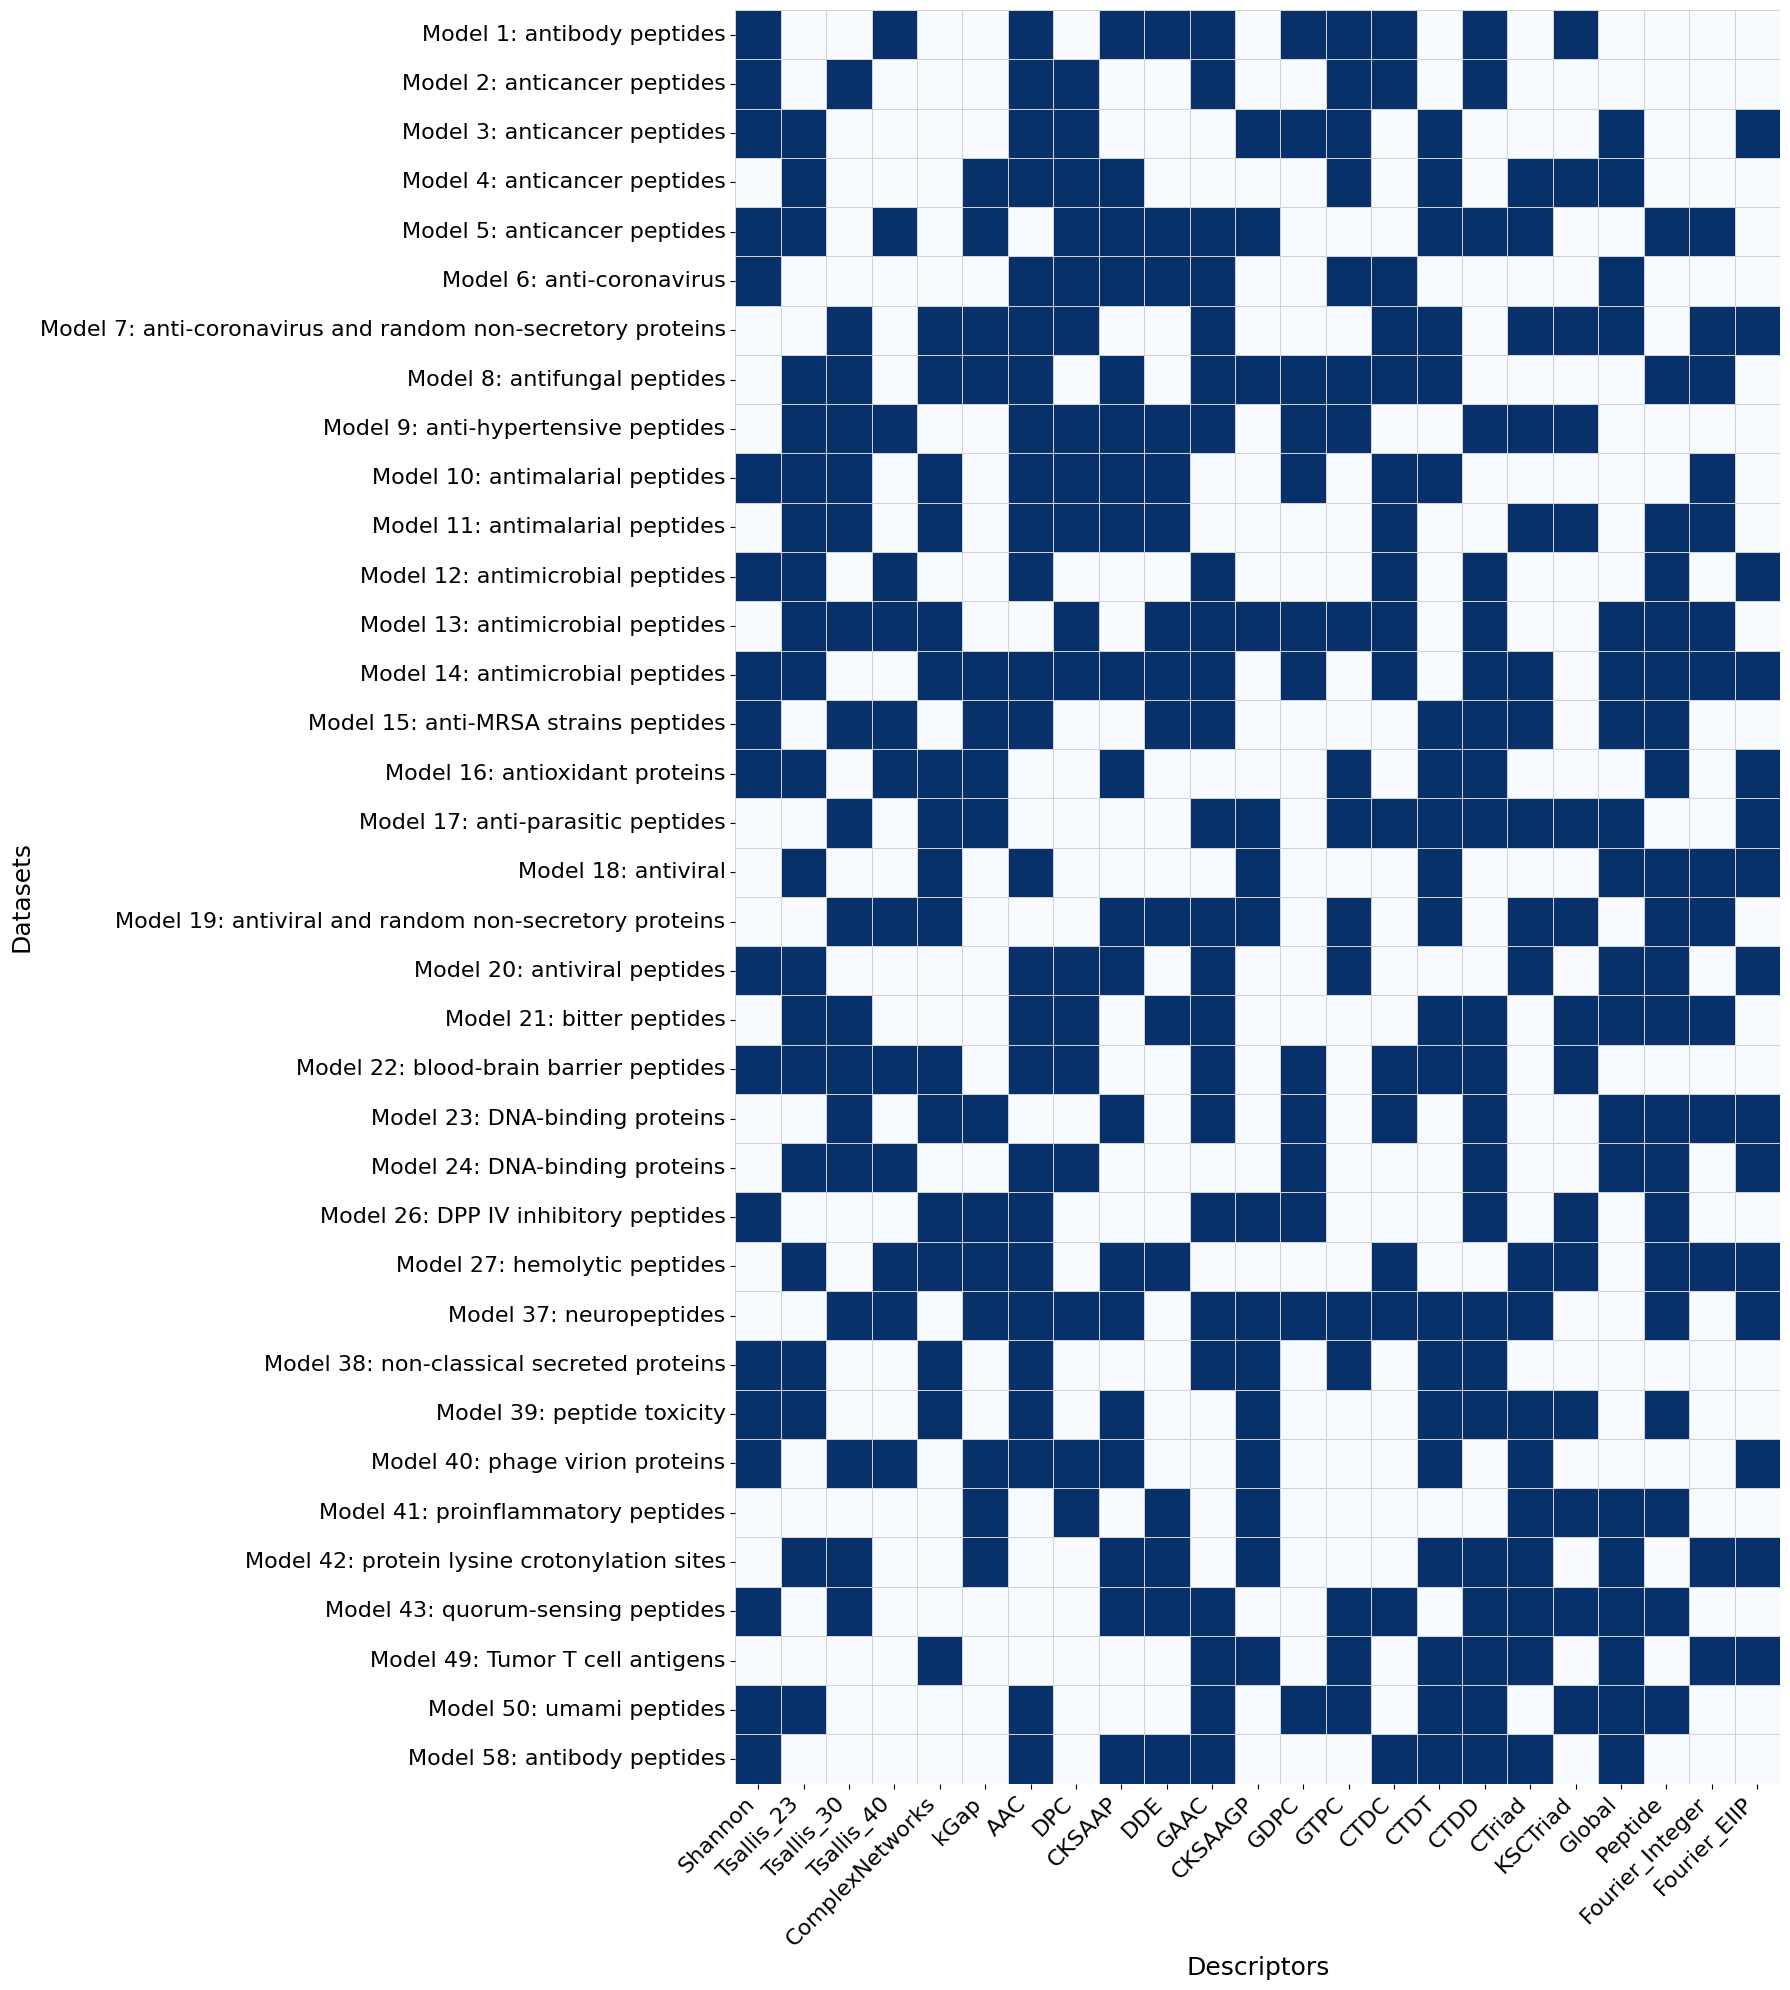

/tmp/ipykernel_2606488/2265836350.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


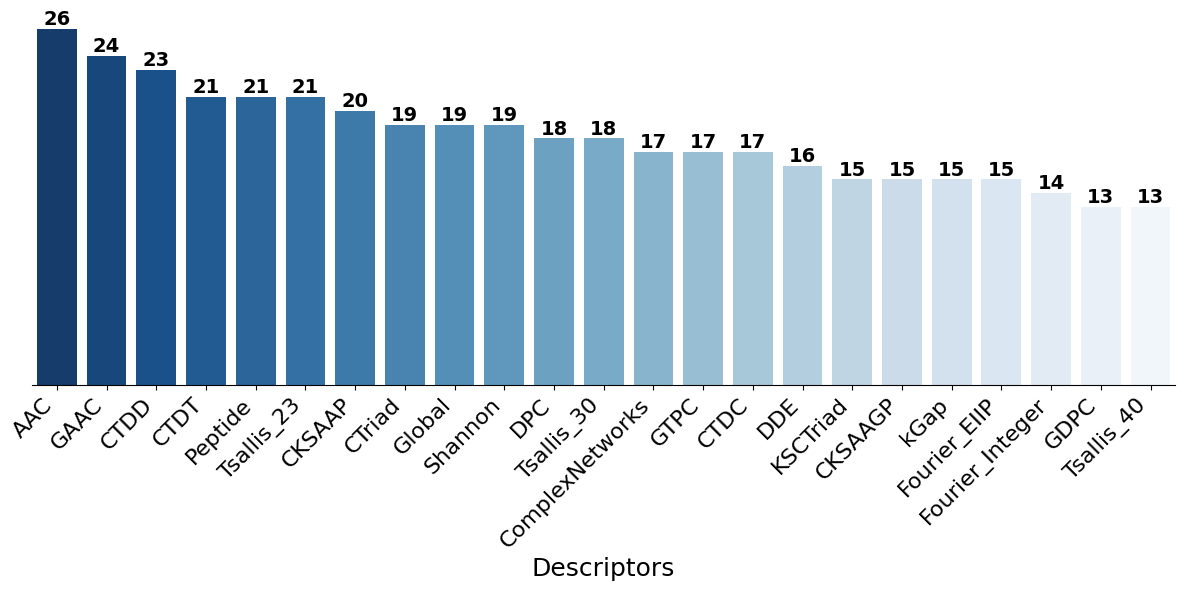

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_indexed = df_final.to_pandas().set_index('dataset')

plt.figure(figsize=(18, 20))
sns.heatmap(
    df_indexed, 
    cmap='Blues',      # White for 0, Blue for 1
    linewidths=0.5,    # Add grid lines
    linecolor='lightgray',
    cbar=False
)

plt.xlabel('Descriptors', fontsize=18)
plt.ylabel('Datasets', fontsize=18)
plt.xticks(fontsize=16, rotation=45, ha='right') # Rotate x labels for readability
plt.yticks(fontsize=16)
plt.tight_layout()
plt.savefig("descriptor_heatmap.svg", format="svg", bbox_inches="tight")
plt.show()

descriptor_frequency = df_indexed.sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x=descriptor_frequency.index,
    y=descriptor_frequency.values,
    palette='Blues_r'
)

# Remove spines and y-axis
sns.despine(ax=ax, left=True)
ax.set_ylabel('')
ax.set_yticks([])

# Add value labels above bars
for i, value in enumerate(descriptor_frequency.values):
    ax.text(
        i,
        value,
        str(int(value)),
        ha='center',
        va='bottom',
        fontsize=14,
        fontweight='bold'
    )

plt.xlabel('Descriptors', fontsize=18)
plt.xticks(fontsize=16, rotation=45, ha='right')
plt.tight_layout()
plt.savefig("descriptor_frequency.svg", format="svg", bbox_inches="tight")
plt.show()

In [ ]:
import joblib

dataset_mapping = {
    "dataset1_liu_protein_0": "Model 1: antibody peptides",
    "dataset2_yu_protein_0": "Model 2: anticancer peptides",
    "dataset3_li_protein_0": "Model 3: anticancer peptides",
    "dataset4_charoenkwan_protein_0": "Model 4: anticancer peptides",
    "dataset5_agrawal_protein_0": "Model 5: anticancer peptides",
    "dataset6_timmons_protein_0": "Model 6: anti-coronavirus",
    "dataset7_timmons_protein_0": "Model 7: anti-coronavirus and random non-secretory proteins",
    "dataset8_pinacho_protein_0": "Model 8: antifungal peptides",
    "dataset9_manavalan_protein_0": "Model 9: anti-hypertensive peptides",
    "dataset10_charoenkwan_protein_0": "Model 10: antimalarial peptides",
    "dataset11_charoenkwan_protein_0": "Model 11: antimalarial peptides",
    "dataset12_chung_protein_0": "Model 12: antimicrobial peptides",
    "dataset13_xiao_protein_0": "Model 13: antimicrobial peptides",
    "dataset14_pang_protein_0": "Model 14: antimicrobial peptides",
    "dataset15_charoenkwan_protein_0": "Model 15: anti-MRSA strains peptides",
    "dataset16_lam_protein_0": "Model 16: antioxidant proteins",
    "dataset17_zhang_protein_0": "Model 17: anti-parasitic peptides",
    "dataset18_timmons_protein_0": "Model 18: antiviral",
    "dataset19_timmons_protein_0": "Model 19: antiviral and random non-secretory proteins",
    "dataset20_pinacho_protein_0": "Model 20: antiviral peptides",
    "dataset21_charoenkwan_protein_0": "Model 21: bitter peptides",
    "dataset22_dai_protein_0": "Model 22: blood-brain barrier peptides",
    "dataset23_chowdhury_protein_0": "Model 23: DNA-binding proteins",
    "dataset24_li_protein_0": "Model 24: DNA-binding proteins",
    "dataset25_liu_dnarna_0": "Model 25: DNase I hypersensitive sites",
    "dataset26_charoenkwan_protein_0": "Model 26: DPP IV inhibitory peptides",
    "dataset27_chaudhary_protein_0": "Model 27: hemolytic peptides",
    "dataset28_khan_dnarna_0": "Model 28: recombination spots",
    "dataset29_han_dnarna_0": "Model 29: lncRNA (Homo sapiens)",
    "dataset30_han_dnarna_0": "Model 30: lncRNA (Mus musculus)",
    "dataset31_han_dnarna_0": "Model 31: lncRNA (Triticum aestivum)",
    "dataset32_meng_dnarna_0": "Model 32: lncRNA (Zea mays)",
    "dataset33_lv_dnarna_0": "Model 33: m5C sites (Arabidopsis thaliana)",
    "dataset34_lv_dnarna_0": "Model 34: m5C sites (Homo sapiens)",
    "dataset35_lv_dnarna_0": "Model 35: m5C sites (Mus musculus)",
    "dataset36_lv_dnarna_0": "Model 36: m5C sites (Saccharomyces cerevisiae)",
    "dataset37_bin_protein_0": "Model 37: neuropeptides",
    "dataset38_zhang_protein_0": "Model 38: non-classical secreted proteins",
    "dataset39_wei_protein_0": "Model 39: peptide toxicity",
    "dataset40_charoenkwan_protein_0": "Model 40: phage virion proteins",
    "dataset41_khatun_protein_0": "Model 41: proinflammatory peptides",
    "dataset42_zhao_protein_0": "Model 42: protein lysine crotonylation sites",
    "dataset43_wei_protein_0": "Model 43: quorum-sensing peptides",
    "dataset44_liu_dnarna_0": "Model 44: real microRNA precursors",
    "dataset45_hoellerer_dnarna_0": "Model 45: ribosome binding site sequences",
    "dataset46_lin_dnarna_0": "Model 46: sigma70 promoters",
    "dataset47_barman_dnarna_0": "Model 47: small non-coding RNA and shuffled sequences",
    "dataset48_valeri_dnarna_0": "Model 48: toehold switch sequences",
    "dataset49_charoenkwan_protein_0": "Model 49: Tumor T cell antigens",
    "dataset50_charoenkwan_protein_0": "Model 50: umami peptides",
    "dataset51_cai_dnarna_0": "Model 51: lncRNAs subcellular localization - training set with 4 classes",
    "dataset52_cai_dnarna_0": "Model 52: lncRNAs subcellular localization - training set with 5 classes",
    "dataset53_musleh_dnarna_0": "Model 53: mRNA subcellular localization",
    "dataset54_avila_dnarna_0": "Model 54: non-coding RNA - 4 classes",
    "dataset55_bonidia_dnarna_0": "Model 55: non-coding RNA - 8 classes",
    "dataset56_bonidia_dnarna_0": "Model 56: non-coding RNA - E. coli K12",
    "dataset57_bonidia_dnarna_0": "Model 57: non-coding RNA - Multiple bacterial phyla",
    "dataset58_liu_protein_1": "Model 58: antibody peptides",
    "dataset59_hoellerer_dnarna_1": "Model 59: ribosome binding site sequences",
    "dataset60_valeri_dnarna_1": "Model 60: toehold switch sequences"
}

full_datasets_path = "App/datasets"
datasets_list = [
    os.path.join(full_datasets_path, item)
    for item in os.listdir(full_datasets_path)
    if os.path.isdir(os.path.join(full_datasets_path, item))
]

df_models = []

for dataset in datasets_list:
    for run in range(1, 6):
        path_model = os.path.join(dataset, f"runs/run_{run}/trained_model.sav")
        if os.path.exists(path_model):
            model = joblib.load(path_model)
            print(model["clf"])

        break
    break

# df_descriptors = pd.concat(df_descriptors).set_index('dataset').fillna(0)
# df_descriptors.index = df_descriptors.index.map(dataset_mapping)
# df_final = (
#     pl.from_pandas(df_descriptors.groupby("dataset").agg(pd.Series.mode).reset_index()).with_columns(
#         pl.col("dataset").str.extract(r"Model (\d+)").cast(pl.Int64).alias("dataset_num")
#     )
#     .sort("dataset_num")
#     .drop("dataset_num")
# )
# df_final

Pipeline(steps=[('imputer', SimpleImputer()),
                ('clf',
                 LGBMClassifier(bagging_fraction=0.830171866071344,
                                bagging_freq=6,
                                feature_fraction=0.5172026848861521,
                                learning_rate=0.28376420602663716,
                                n_estimators=160, num_leaves=29,
                                random_state=63, verbosity=-1))])


In [25]:
df_descriptors

,Shannon,Tsallis_23,Tsallis_30,Tsallis_40,ComplexNetworks,kGap,AAC,DPC,CKSAAP,DDE,...,Tsallis,Revkmer,PseDNC,PseKNC,SC-PseDNC,SC-PseTNC,DAC,TAC,TCC,TACC
dataset,,,,,,,,,,,,,,,,,,,,,
Model 10: antimalarial peptides,1,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model 10: antimalarial peptides,1,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model 10: antimalarial peptides,1,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model 10: antimalarial peptides,0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model 10: antimalarial peptides,0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Model 52: lncRNAs subcellular localization - training set with 5 classes,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0
Model 52: lncRNAs subcellular localization - training set with 5 classes,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0
Model 52: lncRNAs subcellular localization - training set with 5 classes,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
